#### Integrantes:
- Sara Emanuelle Calderón
- Valentina Giraldo Gaviria

# Support Vector Machines

SVMs are among the best (and many believe are indeed the best) “off-the-shelf” supervised learning algorithm. To tell the SVM story, we’ll need to first talk about margins and the idea of separating data with a large “gap.” Next, we’ll talk about the optimal margin classifier, which will lead us into a digression on Lagrange duality. We’ll also see kernels, which give a way to apply SVMs efficiently in very high dimensional (such as infinite-
dimensional) feature spaces.

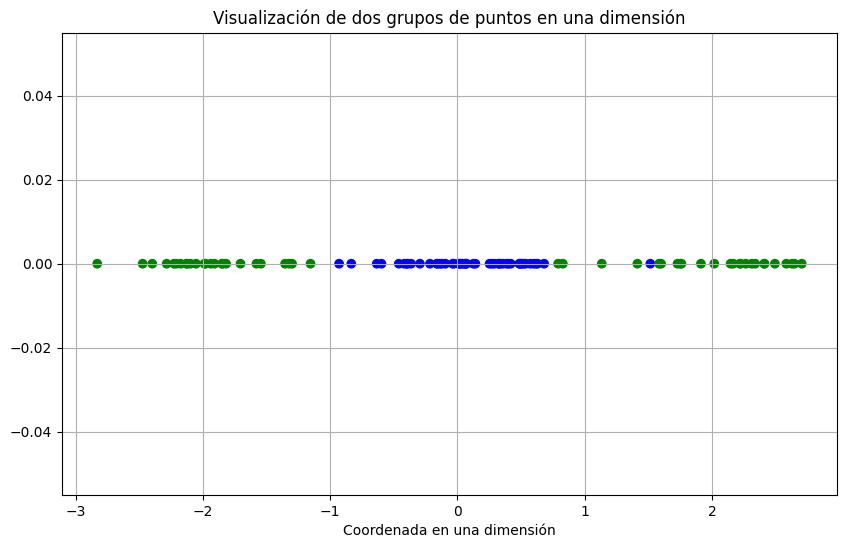

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Generar puntos para el grupo 1 en la parte central
group1 = np.random.normal(loc=0, scale=0.5, size=50)
# Generar puntos para el grupo 2 a los lados del grupo 1
group2 =np.hstack( (np.random.normal(loc=-2, scale=0.5, size=25), np.random.normal(loc=2, scale=0.5, size=25)))
# Concatenar los puntos de los dos grupos
points = np.concatenate([group1, group2])
# Etiquetas para los puntos
labels = np.concatenate([np.zeros(50), np.ones(50)])
# Colores para los puntos según sus etiquetas
colors = {0: 'blue', 1: 'green'}
# Visualización de los puntos en una sola dimensión
plt.figure(figsize=(10, 6))
plt.scatter(points, np.zeros_like(points), c=[colors[label] for label in labels], marker='o')
plt.title('Visualización de dos grupos de puntos en una dimensión')
plt.xlabel('Coordenada en una dimensión')

plt.grid(True)



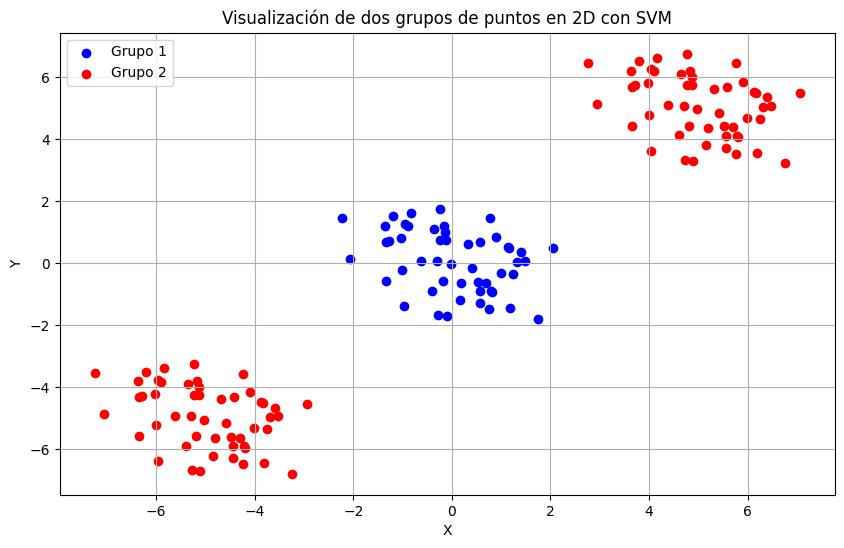

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.svm import SVC

# Generar puntos del grupo 1 en el centro
center_points = np.random.randn(50, 2)

# Generar puntos del grupo 2 a los lados
side_points1 = center_points + np.array([5, 5])
side_points2 = center_points + np.array([-5, -5])

# Combinar los puntos de ambos grupos
X = np.vstack([center_points, side_points1, side_points2])
y = np.hstack([np.zeros(50), np.ones(50), np.ones(50) * 2])
# Visualizar los puntos y el hiperplano de separación
plt.figure(figsize=(10, 6))

# Plot de los puntos del grupo 1
plt.scatter(center_points[:, 0], center_points[:, 1], color='blue', label='Grupo 1')

# Plot de los puntos del grupo 2
plt.scatter(side_points1[:, 0], side_points1[:, 1], color='red', label='Grupo 2')
plt.scatter(side_points2[:, 0], side_points2[:, 1], color='red')


plt.legend()
plt.xlabel('X')
plt.ylabel('Y')
plt.title('Visualización de dos grupos de puntos en 2D con SVM')
plt.grid(True)
plt.show()


### Experiment 1: let's try a linear kernel

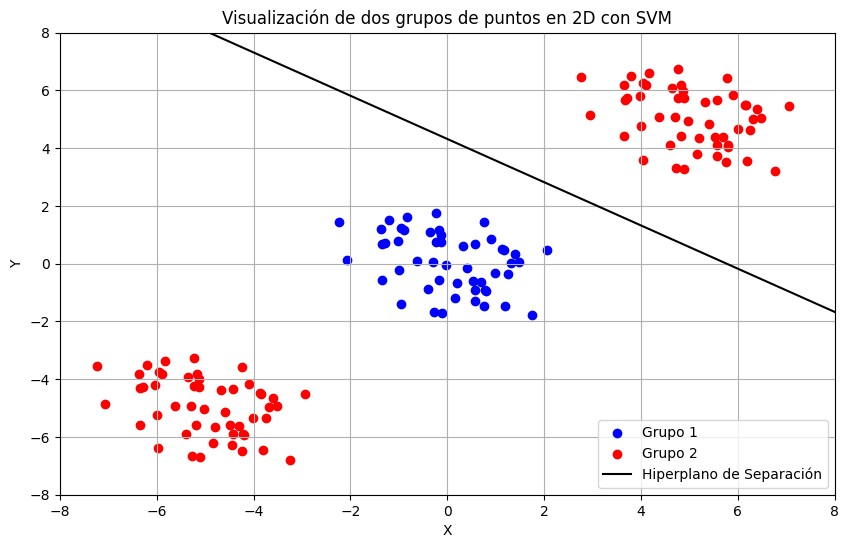

In [3]:
# Visualizar los puntos y el hiperplano de separación
plt.figure(figsize=(10, 6))

# Plot de los puntos del grupo 1
plt.scatter(center_points[:, 0], center_points[:, 1], color='blue', label='Grupo 1')

# Plot de los puntos del grupo 2
plt.scatter(side_points1[:, 0], side_points1[:, 1], color='red', label='Grupo 2')
plt.scatter(side_points2[:, 0], side_points2[:, 1], color='red')


# Entrenar un clasificador SVM
clf = SVC(kernel='linear')
clf.fit(X, y)

# Obtener el hiperplano de separación
w = clf.coef_[0]
a = -w[0] / w[1]
xx = np.linspace(-10, 10)
yy = a * xx - (clf.intercept_[0]) / w[1]

# Plot del hiperplano de separación
plt.plot(xx, yy, 'k-', label='Hiperplano de Separación')

plt.legend()
plt.xlabel('X')
plt.ylabel('Y')
plt.title('Visualización de dos grupos de puntos en 2D con SVM')
plt.grid(True)
plt.axis([-8,8,-8,8])
plt.show()

### Exercise 1
lets implement the Gaussian kernel

Given two data examples, $(x^i,y^i)$ and $(x^j,y^j)$, where the input vectors $x$ have $n$ features. The Gaussian kernel is defined as:


$K(x^i,x^j)= exp(-\frac{|x^i-x^j|^2}{2\sigma^ 2}) = exp(-\frac{\sum_{k=1} ^ n (x^i _k-x^j _k)^2}{2\sigma^2})$


Parameter $\sigma$ controls the decay speed as the vectors $x^i$ and $x^j$ go appart.

### Your task
Implement a  function to compute the Gaussian Kernel, it should receive two feature vectors and a parameter $\sigma$


Once you’ve completed the function gaussianKernel, the next cell  will test your kernel function on two provided examples and you should expect to see a value of:

    1. 0.6669768108584743   if the input is one dimensional
    2. 0.5352614285189903  if the input is two dimensional
    
You must explore how does it affect the value of $\sigma$ when there are points close toguether or far appart.

In [4]:
import numpy as np

In [5]:
def gaussianKernel(x1,x2,sigma):
    K=0
    #your code here

    x1 = np.array(x1)
    x2 = np.array(x2)
    
    # Calculamos la norma euclidiana al cuadrado
    diff = x1 - x2
    norm_sq = np.dot(diff, diff)
    
    # Aplicamos la fórmula del kernel gaussiano
    K = np.exp(-norm_sq / (2 * sigma**2))
    
   
    return K
    

In [6]:
x1 = -2.1
x2 = -1.2
sigma = 1;
K = gaussianKernel(x1, x2, sigma)
print('one dimension:', K)

x1 = np.array([1, 1])
x2 = np.array([1.5, 2]) 
sigma = 1;
K = gaussianKernel(x1, x2, sigma)
print('two dimension:', K)

one dimension: 0.6669768108584743
two dimension: 0.5352614285189903


In [7]:
x1 = -2.1
x2 = -1.2
sigma = 10;
K = gaussianKernel(x1, x2, sigma)
print('one dimension:', K)

x1 = np.array([1, 1])
x2 = np.array([1.5, 2]) 
sigma = 10;
K = gaussianKernel(x1, x2, sigma)
print('two dimension:', K)

one dimension: 0.9959581901895135
two dimension: 0.9937694906233947


In [8]:
x1 = -2.1
x2 = -1.2
sigma = 0.1;
K = gaussianKernel(x1, x2, sigma)
print('one dimension:', K)

x1 = np.array([1, 1])
x2 = np.array([1.5, 2]) 
sigma = 0.1;
K = gaussianKernel(x1, x2, sigma)
print('two dimension:', K)

one dimension: 2.5767571091549626e-18
two dimension: 7.187781739061091e-28


- Con σ = 1: La similitud entre puntos es moderada (≈0.67 en 1D y ≈0.54 en 2D). Esto significa que los puntos cercanos se reconocen como relativamente parecidos, pero aún se distingue claramente la separación conforme aumenta la distancia.

- Con σ = 10: La similitud se vuelve muy alta para casi todos los puntos (≈0.996 en 1D y ≈0.994 en 2D). En este caso, prácticamente cualquier par de observaciones se percibe como “cercano”, lo que suaviza excesivamente la frontera de decisión.El modelo generaliza demasiado (Underfitting)

- Con σ = 0.1: La similitud es casi nula incluso para distancias pequeñas. Esto implica que el modelo considera diferentes a puntos que en realidad están muy próximos, generando fronteras muy ajustadas al ruido. (overfitting).

### Exercise 2
We will begin by with a 2D example dataset which can be separated by a linear boundary. The script will plot the training data. In this dataset, the positions of the positive examples (indicated with +) and the negative examples (indicated with o) suggest a natural separation indicated by the gap. However, notice that there is an outlier positive example + on the far left at about (0.1, 4.1). As part of this exercise, you will also see how
this outlier affects the SVM decision boundary.


In [9]:
import matplotlib.pyplot as plt
from sklearn import svm
%matplotlib inline
########################################################################################
def plot_hyperplane(clf, min_x, max_x, linestyle, label):
    w = clf.coef_[0]
    a = -w[0] / w[1]
    xx = np.linspace(min_x - 2, max_x + 2)  # make sure the line is long enough
    yy = a * xx - (clf.intercept_[0]) / w[1]
    plt.plot(xx, yy, linestyle, label=label)


In this part of the exercise, you will try using different values of the C parameter with SVMs. Informally, the C parameter is a positive value that controls the penalty for misclassified training examples. A large C parameter tells the SVM to try to classify all the examples correctly. C plays a role similar to $\frac{1}{\lambda}$, where $\lambda$ is the regularization parameter that we were using previously for logistic regression.

The next part in run the SVM training (with C = 1) using SVM software that I have included with the starter code, 
When C = 1, you should find that the SVM puts the decision boundary in the gap between the two datasets and misclassifies the data point on the far left.

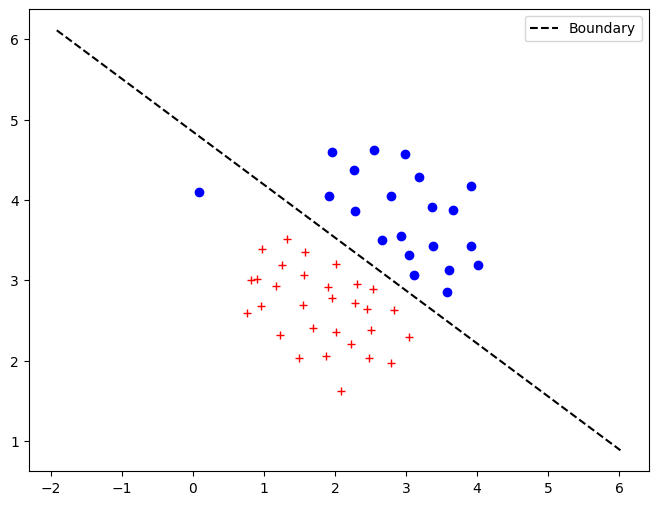

In [ ]:
########################################################################################
#cargar dataset1
data=np.loadtxt(r'dataset1.data',delimiter=',')
X=data[:,:2]
Y=data[:,2].astype(int)
########################
##graficar datos
plt.figure(figsize=(8, 6))

plt.plot(X[Y==0,0],X[Y==0,1],'+r')
plt.plot(X[Y==1,0],X[Y==1,1],'ob')
#create classifiers
C = 1  # parametro de regularizacion de la svm
clf_lin  = svm.SVC(kernel='linear',C=C)

#entrenar
clf_lin.fit(X, Y)
#graficar frontera
min_x=X[:,0].min()
max_x=X[:,0].max()

plot_hyperplane(clf_lin, min_x, max_x, 'k--', label= 'Boundary')
plt.legend();


### Your task
Your task is to try different values of C on this dataset. Specifically, you should change the value of C in the script to C = 100 and run the SVM training again. When C = 100, you should find that the SVM now classifies
every single example correctly, but has a decision boundary that does not appear to be a natural fit for the data

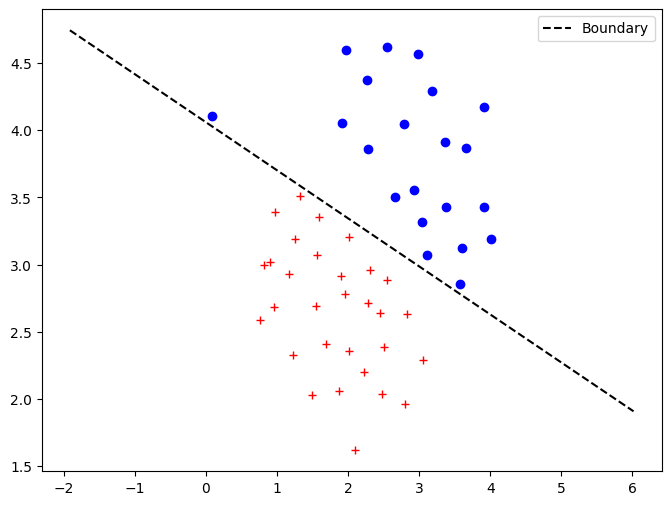

In [11]:
plt.figure(figsize=(8, 6))

plt.plot(X[Y==0,0],X[Y==0,1],'+r')
plt.plot(X[Y==1,0],X[Y==1,1],'ob')
#create classifiers
C = 100  # parametro de regularizacion de la svm
clf_lin  = svm.SVC(kernel='linear',C=C)

#entrenar
clf_lin.fit(X, Y)
#graficar frontera
min_x=X[:,0].min()
max_x=X[:,0].max()

plot_hyperplane(clf_lin, min_x, max_x, 'k--', label= 'Boundary')
plt.legend();

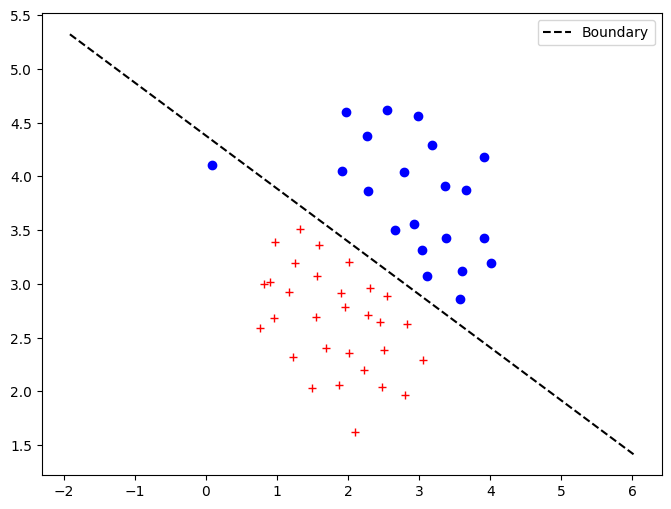

In [12]:
plt.figure(figsize=(8, 6))

plt.plot(X[Y==0,0],X[Y==0,1],'+r')
plt.plot(X[Y==1,0],X[Y==1,1],'ob')
#create classifiers
C = 10  # parametro de regularizacion de la svm
clf_lin  = svm.SVC(kernel='linear',C=C)

#entrenar
clf_lin.fit(X, Y)
#graficar frontera
min_x=X[:,0].min()
max_x=X[:,0].max()

plot_hyperplane(clf_lin, min_x, max_x, 'k--', label= 'Boundary')
plt.legend();

- Con C = 100:
La SVM logra clasificar todos los ejemplos de entrenamiento correctamente . Sin embargo, la frontera de decisión se deforma de manera poco natural para acomodar puntos atípicos o difíciles de separar. Esto se traduce en un margen mucho más estrecho y en un menor número de support vectors. En la práctica, el modelo puede estar sobreajustando (overfitting), ya que prioriza la clasificación perfecta en training a costa de perder capacidad de generalización.

- Con C = 1:
El clasificador tolera algunos errores en los datos de entrenamiento si eso le permite mantener un margen más amplio. La frontera resultante se ve más estable y coherente con la distribución general de los puntos, lo cual suele conducir a una mejor capacidad de generalización hacia nuevos datos.

C grande (hard margin): penaliza con mucha fuerza los errores → el modelo ajusta la frontera a todos los puntos, incluyendo outliers → frontera forzada, riesgo de sobreajuste.

C pequeño (soft margin): permite cierta tolerancia a errores → prioriza un margen ancho y estable → frontera más robusta, mejor generalización.

### Excercise 3
The next part  will load and plot dataset 2. From the plot, you can obserse that there is no linear decision boundary that separates the positive and negative examples for this dataset. However, by using the Gaussian kernel with the SVM, you will be able to learn a non-linear
decision boundary that can perform reasonably well for the dataset.

### Your task
You should change the parameter gamma, it is associated with the parameter $\sigma$, from the first equation.You should not use values higher than 50.

What is the effect of changing the parameter gamma?

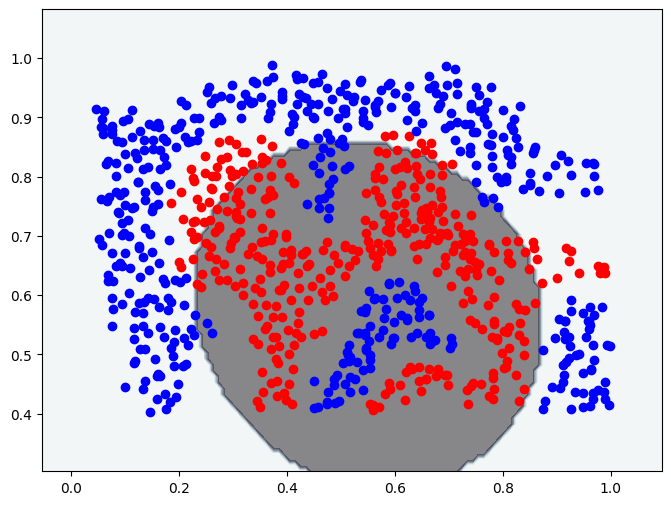

In [ ]:
########################################################################################
def plot_hyperplane(clf, X):
    # create a mesh to plot in
    h=0.01
    x_min, x_max = X[:, 0].min() - 0.1, X[:, 0].max() + 0.1
    y_min, y_max = X[:, 1].min() - 0.1, X[:, 1].max() + 0.1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                     np.arange(y_min, y_max, h))
    Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])
    # Put the result into a color plot
    Z = Z.reshape(xx.shape)

    CS=plt.contourf(xx, yy, Z,cmap=plt.cm.bone,alpha=0.5)
    #CS.cmap.set_under('yellow')
    #CS.cmap.set_over('cyan')

########################################################################################
#cargar dataset2
data=np.loadtxt(r'dataset2.data',delimiter=',')
X=data[:,:2]
Y=data[:,2].astype(int)
########################
##graficar datos
plt.figure(figsize=(8, 6))

plt.plot(X[Y==0,0],X[Y==0,1],'or')
plt.plot(X[Y==1,0],X[Y==1,1],'ob')
########################################################################
#create classifiers
C    = 1  # parametro de regularizacion de la svm
gamma= 1 #parametro gamma de la funcion de base radial
clf_rbf     = svm.SVC(kernel='rbf', gamma=gamma, C=C)
#entrenar
clf_rbf.fit(X, Y)

#graficar frontera
plot_hyperplane(clf_rbf,X)



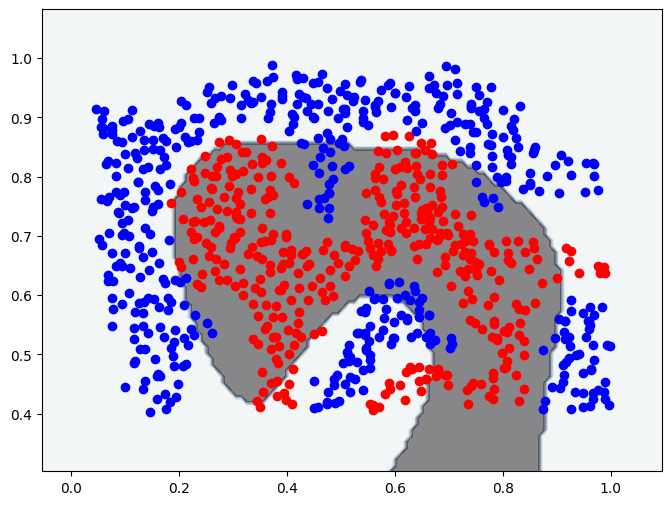

In [14]:
##graficar datos
plt.figure(figsize=(8, 6))

plt.plot(X[Y==0,0],X[Y==0,1],'or')
plt.plot(X[Y==1,0],X[Y==1,1],'ob')
########################################################################
#create classifiers
C    = 1  # parametro de regularizacion de la svm
gamma= 10 #parametro gamma de la funcion de base radial
clf_rbf     = svm.SVC(kernel='rbf', gamma=gamma, C=C)
#entrenar
clf_rbf.fit(X, Y)

#graficar frontera
plot_hyperplane(clf_rbf,X)

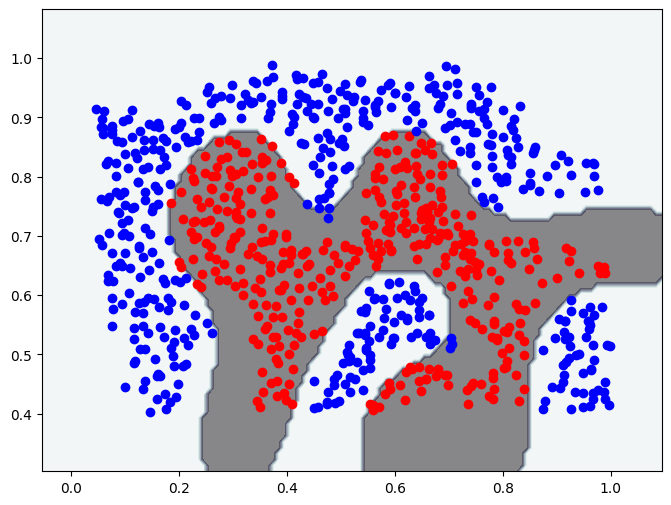

In [15]:
##graficar datos
plt.figure(figsize=(8, 6))

plt.plot(X[Y==0,0],X[Y==0,1],'or')
plt.plot(X[Y==1,0],X[Y==1,1],'ob')
########################################################################
#create classifiers
C    = 1  # parametro de regularizacion de la svm
gamma= 40 #parametro gamma de la funcion de base radial
clf_rbf     = svm.SVC(kernel='rbf', gamma=gamma, C=C)
#entrenar
clf_rbf.fit(X, Y)

#graficar frontera
plot_hyperplane(clf_rbf,X)

- Gamma = 1
El kernel genera fronteras de decisión muy suaves. Esto puede resultar en subajuste (underfitting) si la separación entre clases requiere curvas más complejas, ya que el modelo no capta patrones locales.

- Gamma = 10
Este intervalo suele ofrecer un buen equilibrio entre suavidad y flexibilidad. Permite que el modelo capture la no linealidad de los datos sin ajustarse demasiado al ruido. Es un rango que con frecuencia proporciona el mejor desempeño general (dependiendo del dataset).

- Gamma = 40
El clasificador aprende fronteras altamente complejas, que se adaptan incluso a las irregularidades de los datos. Esto conduce a un sobreajuste (overfitting) probable, donde la frontera refleja ruido y puntos atípicos en lugar de la estructura real de las clases.

γ pequeño ⇒ el radio de influencia de cada punto es grande → similitudes amplias → fronteras suaves → riesgo de subajuste.

γ intermedio ⇒ balance adecuado entre complejidad y generalización.

γ grande ⇒ el radio de influencia es mínimo → cada punto actúa casi de manera aislada → fronteras quebradas y sobreajuste.

### Exercise 4
In this part of the exercise, you will gain more practical skills on how to use a SVM with a Gaussian kernel. The next part will load and display a third dataset. You will be using the SVM with the Gaussian kernel with this dataset.

In the provided dataset, data3, you are given the variables X, y, X_test, y_test. The provided code trains the SVM classifier using the training set (X, y) with some initial parameters. Your task is to use the cross validation set X_test, y_test to determine the best C and gamma parameters to use. You should write any additional code necessary to help you search over the parameters C and gamma. For both C and gamma, It is  suggested trying values in multiplicative steps (e.g., 0.01, 0.03, 0.1, 0.3, 1, 3, 10, 30).

Note that you should try all possible pairs of values for C and gamma (e.g., C = 0.3 and gamma = 0.1). For example, if you try each of the 8 values listed above for C
and for gamma , you would end up training and evaluating (on the cross validation set) a total of 8 x 8 = 64 different models.

In [16]:
from sklearn.model_selection import GridSearchCV


Top pares (C, gamma, acc_valid):
C=3.0, gamma=30.0 -> acc_valid=0.9650
C=30.0, gamma=10.0 -> acc_valid=0.9650
C=0.3, gamma=30.0 -> acc_valid=0.9600
C=1.0, gamma=30.0 -> acc_valid=0.9600
C=3.0, gamma=3.0 -> acc_valid=0.9600
C=30.0, gamma=30.0 -> acc_valid=0.9600
C=0.3, gamma=10.0 -> acc_valid=0.9550
C=3.0, gamma=10.0 -> acc_valid=0.9550
C=0.1, gamma=30.0 -> acc_valid=0.9500
C=1.0, gamma=3.0 -> acc_valid=0.9500

Mejor par: C=3.0, gamma=30.0 | Accuracy validación = 0.9650 (96.50%)


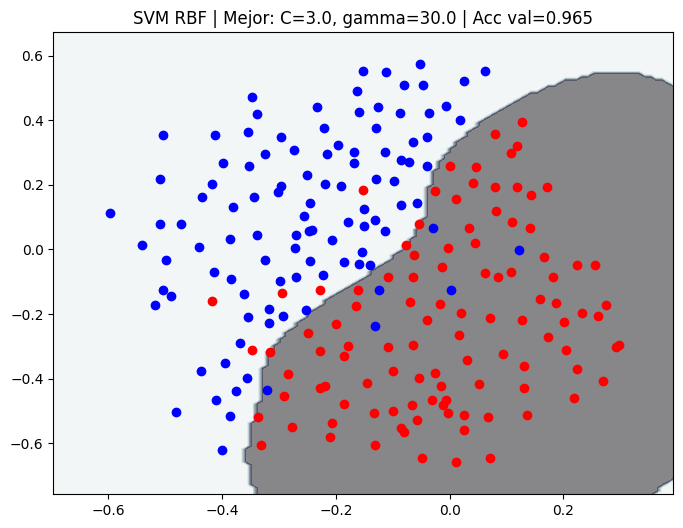

In [ ]:
########################################################################################
def plot_hyperplane(clf, X):
    # create a mesh to plot in
    h=0.01
    x_min, x_max = X[:, 0].min() - 0.1, X[:, 0].max() + 0.1
    y_min, y_max = X[:, 1].min() - 0.1, X[:, 1].max() + 0.1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                     np.arange(y_min, y_max, h))
    Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])
    # Put the result into a color plot
    Z = Z.reshape(xx.shape)

    CS=plt.contourf(xx, yy, Z,cmap=plt.cm.bone,alpha=0.5)
    #CS.cmap.set_under('yellow')
    #CS.cmap.set_over('cyan')


########################################################################################
#cargar dataset3: conjunto de entrenamiento y conjunto de prueba
data=np.loadtxt(r'dataset3_train.data',delimiter=',')
X=data[:,:2]
y=data[:,2].astype(int)
data=np.loadtxt(r'dataset3_test.data',delimiter=',')
X_test=data[:,:2]
y_test=data[:,2].astype(int)

########################

##graficar datos de entrenamiento
plt.figure(figsize=(8, 6))

plt.plot(X[y==0,0],X[y==0,1],'or')
plt.plot(X[y==1,0],X[y==1,1],'ob')

########################################################################
C=np.array([0.01, 0.03, 0.1,0.3, 1,3,10,30])       
gamma=np.array([0.01, 0.03, 0.1,0.3, 1,3,10,30])
## su codigo va aqui #########

best_acc = -1.0
best_params = (None, None)
clf_rbf = None  # aquí guardaremos el mejor clasificador ya entrenado
scores = []

for c in C.astype(float):
    for g in gamma.astype(float):
        clf = svm.SVC(kernel='rbf', C=c, gamma=g)
        clf.fit(X, y)                              # entreno en TRAIN
        acc = (clf.predict(X_test) == y_test).mean()  # evalúo en VALID
        scores.append((c, g, acc))
        if acc > best_acc:
            best_acc = acc
            best_params = (c, g)
            clf_rbf = clf                         # guardo el mejor ya entrenado

# Top resultados (opcional)
scores.sort(key=lambda t: t[2], reverse=True)
print("Top pares (C, gamma, acc_valid):")
for c, g, acc in scores[:10]:
    print(f"C={c}, gamma={g} -> acc_valid={acc:.4f}")

print(f"\nMejor par: C={best_params[0]}, gamma={best_params[1]} | "
      f"Accuracy validación = {best_acc:.4f} ({best_acc*100:.2f}%)")

# Graficar la frontera del MEJOR modelo en la misma figura
plot_hyperplane(clf_rbf, X)
plt.title(f"SVM RBF | Mejor: C={best_params[0]}, gamma={best_params[1]} | Acc val={best_acc:.3f}")
plt.show()



Gamma alto (≈10–30) → radio de influencia local; el modelo capta patrones finos necesarios para este dataset.

C moderado (≈1–10) → penaliza errores sin forzar la frontera a acomodar outliers; ayuda a generalizar mejor que 
C excesivamente grande.

Par empatado: 
(C=30, Gamma =10) obtiene 96.5%. Esto indica un trade-off: con Gamma algo menor, un C mayor compensa manteniendo el desempeño.

## Your conclussions?

#### 1) Rol de σ 

- σ intermedio (γ moderado) → mantiene una similitud moderada entre puntos, captando relaciones locales sin ser demasiado sensible al ruido.

- σ grande (γ pequeño) → casi todos los puntos se perciben como similares, lo que produce fronteras demasiado suaves y riesgo de underfitting.

- σ pequeño (γ grande) → solo puntos muy cercanos se consideran parecidos, lo que genera fronteras muy sinuosas y riesgo de overfitting.
→ σ/γ controla el “radio de proximidad”: más grande = visión global; más pequeño = enfoque local.

#### 2) Efecto del parámetro C en SVM lineal

- C grande → penaliza con mucha fuerza los errores, buscando separar perfectamente los datos. Esto genera márgenes estrechos y fronteras forzadas por outliers (riesgo de overfitting).

- C pequeño → tolera algunos errores si eso permite márgenes amplios. Esto produce fronteras más estables y con mejor capacidad de generalización.
→ C actúa como regulador entre rigidez y flexibilidad: alto = ajuste estricto, bajo = tolerancia y generalización.

#### 3) Efecto del parámetro γ en SVM RBF

- γ muy bajo : fronteras casi lineales, riesgo de underfitting.

- γ intermedio : buen equilibrio entre complejidad y suavidad, frecuentemente el rango más útil.

- γ alto (10–50): fronteras muy complejas y curvas, capaces de adaptarse a puntos atípicos pero con riesgo de overfitting.

#### 4) Resultados experimentales con dataset3

- El mejor modelo: C=3.0, γ=30.0, con 96.5% de accuracy en validación.

- Hubo empates cercanos (p. ej., C=30, γ=10 también con 96.5%), lo que muestra que distintos pares de parámetros pueden lograr resultados similares ajustando el balance entre rigidez (C) y radio de influencia (γ). Sin embargo, prima el equilibrio entre precisión y generalización.

- La frontera obtenida con el mejor par es no lineal, coherente con la distribución de los datos y suficientemente flexible para separar clases, sin llegar a ser caótica.

#### 5)
 A lo largo del ejercicio se evidenció que el objetivo principal de un modelo de clasificación no es lograr un ajuste perfecto a los datos de entrenamiento, sino encontrar un equilibrio entre precisión y capacidad de generalización. Cuando un modelo clasifica absolutamente todos los puntos del conjunto de entrenamiento, puede parecer ideal; sin embargo, esto suele ser señal de sobreajuste (overfitting), lo que implica que el modelo ha memorizado los datos en lugar de aprender el patrón subyacente. En consecuencia, su rendimiento en datos nuevos puede ser significativamente peor.
#### 6)
 El parámetro 𝐶 regula el nivel de penalización que el modelo aplica a los errores de clasificación. Un valor pequeño de 𝐶 favorece márgenes más amplios y modelos más simples, tolerando algunos errores en favor de una mejor generalización. Por el contrario, un valor grande de 𝐶 obliga al modelo a corregir la mayor cantidad posible de errores, lo que puede llevar a fronteras más complejas y al riesgo de sobreajuste. La elección adecuada de 𝐶 permite que el modelo aprenda con precisión sin perder estabilidad.
#### 7) 
El parámetro 𝛾 controla el grado de influencia de cada punto de entrenamiento y determina qué tan flexible será la frontera de decisión. Valores bajos producen fronteras suaves y generalistas, pero pueden caer en subajuste si el modelo no logra capturar la complejidad de los datos. En cambio, valores altos hacen que la frontera se ajuste estrechamente a los puntos, mejorando la precisión en entJrenamiento pero aumentando el riesgo de sobreajuste. Por tanto, la selección de 𝛾 es importante para lograr un equilibrio entre simplicidad y detalle.
#### 8) 
Más allá de la métrica de accuracy, el análisis de las fronteras de decisión fue clave para comprender el comportamiento del modelo. Las gráficas permitieron observar si el modelo estaba subajustando, sobreajustando o si se encontraba en el punto de equilibrio adecuado. Esto demuestra que la evaluación visual es una herramienta complementaria valiosa para la toma de decisiones en el ajuste de modelos de machine learning.